In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_train = pd.read_csv("Files/train.csv", index_col="Id")
data_test = pd.read_csv("Files/test.csv", index_col="Id")

In [ ]:
#Null Werte raus

In [34]:
data_train.isnull().sum().sort_values(ascending=False)

MSSubClass      0
Electrical      0
GarageFinish    0
GarageYrBlt     0
GarageType      0
               ..
ExterQual       0
MasVnrArea      0
MasVnrType      0
Exterior2nd     0
has_Pool        0
Length: 81, dtype: int64

In [5]:
data_train["has_Pool"] = (data_train["PoolArea"] > 0).astype(int)
data_test["has_Pool"] = (data_test["PoolArea"] > 0).astype(int)

In [9]:
data_train["MasVnrType"].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [17]:
data_train[data_train['LotFrontage'].isna()]['BldgType'].value_counts()

BldgType
1Fam      226
TwnhsE     22
Duplex      5
Twnhs       3
2fmCon      3
Name: count, dtype: int64

In [21]:
data_train["BldgType"].value_counts()

BldgType
1Fam      1220
TwnhsE     114
Duplex      52
Twnhs       43
2fmCon      31
Name: count, dtype: int64

In [20]:
data_train[data_train["BldgType"] == "1Fam"]["LotFrontage"].value_counts()

LotFrontage
60.0     122
80.0      67
70.0      64
50.0      50
75.0      48
        ... 
160.0      1
152.0      1
41.0       1
153.0      1
46.0       1
Name: count, Length: 104, dtype: int64

In [22]:
for df in [data_train, data_test]:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

In [27]:
na_meaning = {
    "Alley": "No Alley",
    "BsmtQual": "No Basement",
    "BsmtCond": "No Basement",
    "BsmtFinType1": "No Basement",
    "BsmtFinType2": "No Basement",
    "BsmtExposure": "No Basement",
    "FireplaceQu": "No Fireplace",
    "GarageType": "No Garage",
    "GarageFinish": "No Garage",
    "GarageQual": "No Garage",
    "GarageCond": "No Garage",
    "GarageYrBlt": "No Garage",
    "PoolQC": "No Pool",
    "Fence": "No Fence",
    "MiscFeature": "No Misc",
    "MasVnrType": "None",
    "MasVnrArea": 0,
}
for col, fill_val in na_meaning.items():
    data_train[col] = data_train[col].fillna(fill_val)
    data_test[col] = data_test[col].fillna(fill_val)

In [32]:
data_train["Electrical"] = data_train["Electrical"].fillna(data_train["Electrical"].mode()[0])

In [ ]:
#Outlier

In [69]:
numericalcols = data_train.select_dtypes(include="number").columns
numericalcols

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice', 'has_Pool'],
      dtype='str')

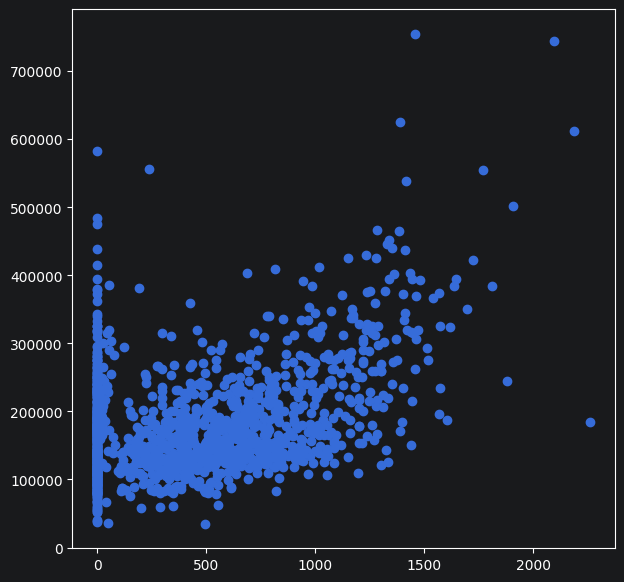

In [76]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x = data_train["BsmtFinSF1"], y=data_train["SalePrice"]);

In [56]:
data_train[data_train['LotArea'] > 100000][['LotFrontage', 'SalePrice', 'Neighborhood', 'BldgType', 'LotArea']]

,LotFrontage,SalePrice,Neighborhood,BldgType,LotArea
Id,,,,,
250,80.0,277000,ClearCr,1Fam,159000
314,150.0,375000,Timber,1Fam,215245
336,85.0,228950,Timber,2fmCon,164660
707,80.0,302000,ClearCr,1Fam,115149


In [73]:
data_train["LotArea"].describe()

count     1460.000000
mean     10139.083359
std       5522.483610
min       1300.000000
25%       7553.500000
50%       9478.500000
75%      11601.500000
max      45924.392000
Name: LotArea, dtype: float64

In [62]:
data_train["LotArea"].quantile([0.95,0.98,0.992])

0.950    17401.150
0.980    25251.620
0.992    45924.392
Name: LotArea, dtype: float64

In [63]:
upper = data_train["LotArea"].quantile(0.992)
data_train['LotArea'] = data_train["LotArea"].clip(upper=upper)

In [71]:
data_train.loc[data_train["BsmtFinSF1"] > 3000]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,has_Pool
Id,,,,,,,,,,,,,,,,,,,,,
1299,60,RL,313.0,45924.392,Pave,No Alley,IR3,Bnk,AllPub,Corner,...,Gd,No Fence,No Misc,0,1,2008,New,Partial,160000,1


In [75]:
data_train = data_train.drop(index=1299)